# 05. Distance-Based Methods: kNN and Local Outlier Factor

The previous notebook used statistical detectors: robust z-scores, Mahalanobis distance, and robust covariance. Those methods work well when the normal region can be summarized by center, scale, and covariance.

Distance-based anomaly detection takes a different view. Instead of fitting a parametric baseline, it asks whether a point has nearby neighbors. A case is suspicious if it is far from other cases or if it sits in a region that is much less dense than the local region around its neighbors.

This notebook focuses on two foundational ideas:

1. **k-nearest-neighbor distance scores:** a point is anomalous if its nearest neighbors are far away.
2. **Local Outlier Factor (LOF):** a point is anomalous if its local density is much lower than the density of its neighbors.

The decision-science theme is: distance methods are intuitive, flexible, and useful for irregular data, but they are extremely sensitive to feature scaling, neighborhood size, density variation, and operational thresholding.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why feature scaling is not optional for distance-based anomaly detection.
2. Define a k-nearest-neighbor distance score.
3. Explain how the neighborhood size $k$ changes the detector's behavior.
4. Define reachability distance, local reachability density, and Local Outlier Factor.
5. Compare global distance scoring with local density scoring.
6. Diagnose when kNN distance falsely flags legitimate sparse operating regimes.
7. Evaluate distance-based detectors using fixed review budgets.
8. Translate kNN and LOF scores into an operational alert policy and decision memo.

In [1]:
# Section focus: Learning Objectives.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 180)

RANDOM_SEED = 2030

## 1. Distance-Based Anomaly Detection

Let $x_i \in \mathbb{R}^p$ be a feature vector. A distance-based detector needs a distance function, usually Euclidean distance after preprocessing:

$$
d(x_i, x_j) = \left\lVert z_i - z_j \right\rVert_2,
$$

where $z_i$ is a scaled version of $x_i$.

A common kNN anomaly score is the distance from $x_i$ to its $k$th nearest neighbor:

$$
S_i^{\mathrm{kNN}} = d_k(x_i).
$$

Another version uses the average distance to the first $k$ neighbors:

$$
\bar{S}_i^{\mathrm{kNN}} = \frac{1}{k}\sum_{j \in N_k(i)} d(x_i, x_j).
$$

Large values mean the point is isolated. This idea goes back to distance-based outlier mining formulations that rank points by their distance to the $k$th nearest neighbor (Ramaswamy et al., 2000).

### Why Scaling Is Part of the Model

If one feature is measured in dollars and another is measured in percentages, raw Euclidean distance will mostly measure the dollar feature. Standardization changes the geometry:

$$
z_{ij} = \frac{x_{ij} - \hat{\mu}_j}{\hat{\sigma}_j}.
$$

This is not a cosmetic step. It defines what "near" means. If a feature should matter more, that should be an explicit weighting decision rather than an accident of measurement units.

## 2. Local Density and LOF

kNN distance is a global isolation score. It can struggle when normal data contain regions of different density. A sparse-but-normal operating regime may have larger neighbor distances than a dense normal regime.

Local Outlier Factor solves this by comparing a point's density to the density of its neighbors (Breunig et al., 2000). Define the $k$-distance of point $o$ as the distance to its $k$th nearest neighbor. The reachability distance from $p$ to $o$ is

$$
\operatorname{reach\_dist}_k(p,o) = \max\{k\text{-distance}(o), d(p,o)\}.
$$

The local reachability density of $p$ is

$$
\operatorname{lrd}_k(p) =
\left(
\frac{1}{|N_k(p)|}\sum_{o \in N_k(p)} \operatorname{reach\_dist}_k(p,o)
\right)^{-1}.
$$

The Local Outlier Factor is

$$
\operatorname{LOF}_k(p) =
\frac{1}{|N_k(p)|}\sum_{o \in N_k(p)}
\frac{\operatorname{lrd}_k(o)}{\operatorname{lrd}_k(p)}.
$$

A value near 1 means the point has density similar to its neighbors. Values greater than 1 mean the point is locally sparse relative to nearby points.

## 3. Synthetic Case: Service Operations Monitoring

Imagine a digital service platform that monitors short operating windows across customer support and operational workflows. The platform serves two normal operating regimes:

| Regime | Description |
|---|---|
| `standard` | High-volume, relatively dense operating windows |
| `enterprise` | Lower-volume, more complex, naturally sparse operating windows |

The team wants to detect unusual operating windows for review. Some anomalies are globally isolated. Others are local anomalies near a regime where raw distance alone can be misleading.

The row grain is one operating window. Standard and enterprise windows are both normal, but they occupy different parts of feature space. That detail matters because distance-based detectors can confuse sparse but legitimate enterprise behavior with true anomalies.

The experiment asks whether kNN distance and LOF can find unusual operating states without overwhelming the review queue with structurally different normal cases. The synthetic labels let us evaluate precision and recall, while the realistic lesson is about alert burden, neighborhood choice, and the danger of treating all sparsity as risk.


In [2]:
# Section focus: 3. Synthetic Case: Service Operations Monitoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_service_operations(n_standard=3300, n_enterprise=950, n_anomaly=240, seed=RANDOM_SEED):
    """Create a simulated service operations data set for the 05. Distance-Based Methods: kNN and Local Outlier Factor case study.
    
    Parameters
    ----------
    n_standard : object
        Count or size setting for the service operations calculation.
    n_enterprise : object
        Count or size setting for the service operations calculation.
    n_anomaly : object
        Count or size setting for the service operations calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    features = [
        'ticket_volume',
        'median_resolution_minutes',
        'escalation_rate_pct',
        'reopen_rate_pct',
        'cost_per_ticket',
        'customer_risk_score',
    ]

    standard_mean = np.array([115, 42, 7.5, 4.8, 21, 34])
    enterprise_mean = np.array([44, 94, 17.0, 8.5, 63, 71])
    standard_scale = np.array([18, 8, 1.8, 1.2, 4.5, 8])
    enterprise_scale = np.array([13, 18, 3.8, 2.0, 13, 11])

    corr = np.array([
        [1.00, -0.20, 0.10, 0.05, -0.15, -0.10],
        [-0.20, 1.00, 0.48, 0.36, 0.58, 0.42],
        [0.10, 0.48, 1.00, 0.44, 0.36, 0.50],
        [0.05, 0.36, 0.44, 1.00, 0.30, 0.38],
        [-0.15, 0.58, 0.36, 0.30, 1.00, 0.34],
        [-0.10, 0.42, 0.50, 0.38, 0.34, 1.00],
    ])

    standard_cov = np.outer(standard_scale, standard_scale) * corr
    enterprise_cov = np.outer(enterprise_scale, enterprise_scale) * corr
    standard = rng.multivariate_normal(standard_mean, standard_cov, n_standard)
    enterprise = rng.multivariate_normal(enterprise_mean, enterprise_cov, n_enterprise)

    anomaly_types = rng.choice(
        ['global_service_breakdown', 'local_enterprise_degradation', 'mixed_regime_bridge'],
        size=n_anomaly,
        p=[0.36, 0.38, 0.26],
    )
    anomalies = []
    for kind in anomaly_types:
        if kind == 'global_service_breakdown':
            point = rng.multivariate_normal(
                np.array([172, 135, 29, 19, 91, 89]),
                np.diag([18, 24, 5.5, 3.5, 18, 9]) ** 2,
            )
        elif kind == 'local_enterprise_degradation':
            point = rng.multivariate_normal(
                np.array([47, 142, 28, 15, 89, 78]),
                np.diag([9, 12, 3.2, 2.2, 9, 8]) ** 2,
            )
        else:
            # Between the two normal regimes: not globally extreme on every axis, but locally unusual.
            point = rng.multivariate_normal(
                np.array([78, 73, 22, 12, 44, 53]),
                np.diag([8, 9, 2.6, 1.8, 7, 7]) ** 2,
            )
        anomalies.append(point)
    anomalies = np.vstack(anomalies)

    X = np.vstack([standard, enterprise, anomalies])
    X[:, 0] = np.clip(X[:, 0], 1, None)
    X[:, 1] = np.clip(X[:, 1], 1, None)
    X[:, 2:4] = np.clip(X[:, 2:4], 0, 100)
    X[:, 4] = np.clip(X[:, 4], 1, None)
    X[:, 5] = np.clip(X[:, 5], 0, 100)

    df = pd.DataFrame(X, columns=features)
    df['regime'] = ['standard'] * n_standard + ['enterprise'] * n_enterprise + ['investigate'] * n_anomaly
    df['known_anomaly'] = [0] * (n_standard + n_enterprise) + [1] * n_anomaly
    df['anomaly_type'] = ['normal_standard'] * n_standard + ['normal_enterprise'] * n_enterprise + list(anomaly_types)
    df['review_minutes'] = np.where(
        df['regime'].eq('enterprise'),
        rng.normal(20, 4, len(df)),
        rng.normal(13, 3, len(df)),
    )
    df.loc[df['known_anomaly'].eq(1), 'review_minutes'] += rng.normal(8, 3, df['known_anomaly'].sum())
    df['review_minutes'] = df['review_minutes'].clip(5, 45)
    return df, features


df, features = simulate_service_operations()
smart_display(df.head(), max_width='980px')

,ticket_volume,median_resolution_minutes,escalation_rate_pct,reopen_rate_pct,cost_per_ticket,customer_risk_score,regime,known_anomaly,anomaly_type,review_minutes
0,117.559272,28.778913,7.675798,4.303261,25.616189,35.461341,standard,0,normal_standard,12.841693
1,66.796477,61.248057,5.515579,6.377027,23.314418,37.206394,standard,0,normal_standard,14.742321
2,121.876107,26.520129,6.387028,2.362257,17.159838,33.168228,standard,0,normal_standard,9.947069
3,128.614856,32.171387,4.735221,3.600994,18.947602,16.860152,standard,0,normal_standard,8.223741
4,139.694795,27.277298,6.827703,3.705503,12.967994,26.592407,standard,0,normal_standard,12.075083


Synthetic Case: Service Operations Monitoring should be read as an operations question. The score should help reviewers focus, rather than simply add another number to the queue.


In [3]:
summary = pd.DataFrame({
    'Quantity': [
        'Operating windows',
        'Known anomaly rate',
        'Standard normal windows',
        'Enterprise normal windows',
        'Features used for distance',
        'Median review minutes',
    ],
    'Value': [
        f'{len(df):,}',
        f"{df['known_anomaly'].mean():.1%}",
        f"{df['anomaly_type'].eq('normal_standard').sum():,}",
        f"{df['anomaly_type'].eq('normal_enterprise').sum():,}",
        len(features),
        f"{df['review_minutes'].median():.1f}",
    ],
})
smart_display(summary, max_width='780px')

smart_display(
    df['anomaly_type'].value_counts().rename_axis('window_type').reset_index(name='count'),
    max_width='760px',
)

,Quantity,Value
0,Operating windows,"4,490"
1,Known anomaly rate,5.3%
2,Standard normal windows,"3,300"
3,Enterprise normal windows,950
4,Features used for distance,6
5,Median review minutes,14.2


,window_type,count
0,normal_standard,3300
1,normal_enterprise,950
2,local_enterprise_degradation,91
3,global_service_breakdown,86
4,mixed_regime_bridge,63


This case is designed to expose an important distinction. Enterprise windows are normal but less dense than standard windows. A global distance detector may over-alert them. LOF is designed to be more forgiving when sparse points are locally similar to nearby sparse points, but that is a hypothesis to check, not something to assume. In heterogeneous operational data, the neighborhood graph itself can mix normal regimes, bridge cases, and true anomalies in ways that make LOF fragile.


## 4. Feature Scaling and kNN Scores

We will compute nearest-neighbor distances twice:

1. On raw features, where large-scale variables dominate distance.
2. On standardized features, where every feature starts with comparable scale.

For each point, we compute the average distance to the first $k$ neighbors, excluding the point itself. The detector score is

$$
S_i = \frac{1}{k}\sum_{j \in N_k(i)} d(z_i,z_j).
$$

In [4]:
# Section focus: 4. Feature Scaling and kNN Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

k = 25
review_rate = 0.04

X_raw = df[features].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

raw_neighbors = NearestNeighbors(n_neighbors=k + 1).fit(X_raw)
raw_distances, raw_indices = raw_neighbors.kneighbors(X_raw)
scaled_neighbors = NearestNeighbors(n_neighbors=k + 1).fit(X_scaled)
scaled_distances, scaled_indices = scaled_neighbors.kneighbors(X_scaled)

# Column 0 is the point itself, so remove it.
df['knn_raw_mean_distance'] = raw_distances[:, 1:].mean(axis=1)
df['knn_scaled_mean_distance'] = scaled_distances[:, 1:].mean(axis=1)
df['knn_scaled_k_distance'] = scaled_distances[:, -1]

knn_cut_raw = df['knn_raw_mean_distance'].quantile(1 - review_rate)
knn_cut_scaled = df['knn_scaled_mean_distance'].quantile(1 - review_rate)

score_summary = pd.DataFrame({
    'score': ['Raw kNN mean distance', 'Scaled kNN mean distance'],
    'cutoff_top_4_percent': [knn_cut_raw, knn_cut_scaled],
    'alert_rate': [
        (df['knn_raw_mean_distance'] >= knn_cut_raw).mean(),
        (df['knn_scaled_mean_distance'] >= knn_cut_scaled).mean(),
    ],
})
score_summary_display = score_summary.copy()
score_summary_display['cutoff_top_4_percent'] = score_summary_display['cutoff_top_4_percent'].map(lambda value: f'{value:.2f}')
score_summary_display['alert_rate'] = score_summary_display['alert_rate'].map(lambda value: f'{value:.1%}')
smart_display(score_summary_display, max_width='760px')

,score,cutoff_top_4_percent,alert_rate
0,Raw kNN mean distance,17.86,4.0%
1,Scaled kNN mean distance,1.07,4.0%


In Feature Scaling and kNN Scores, the detector earns its keep only if the output sharpens the review queue.


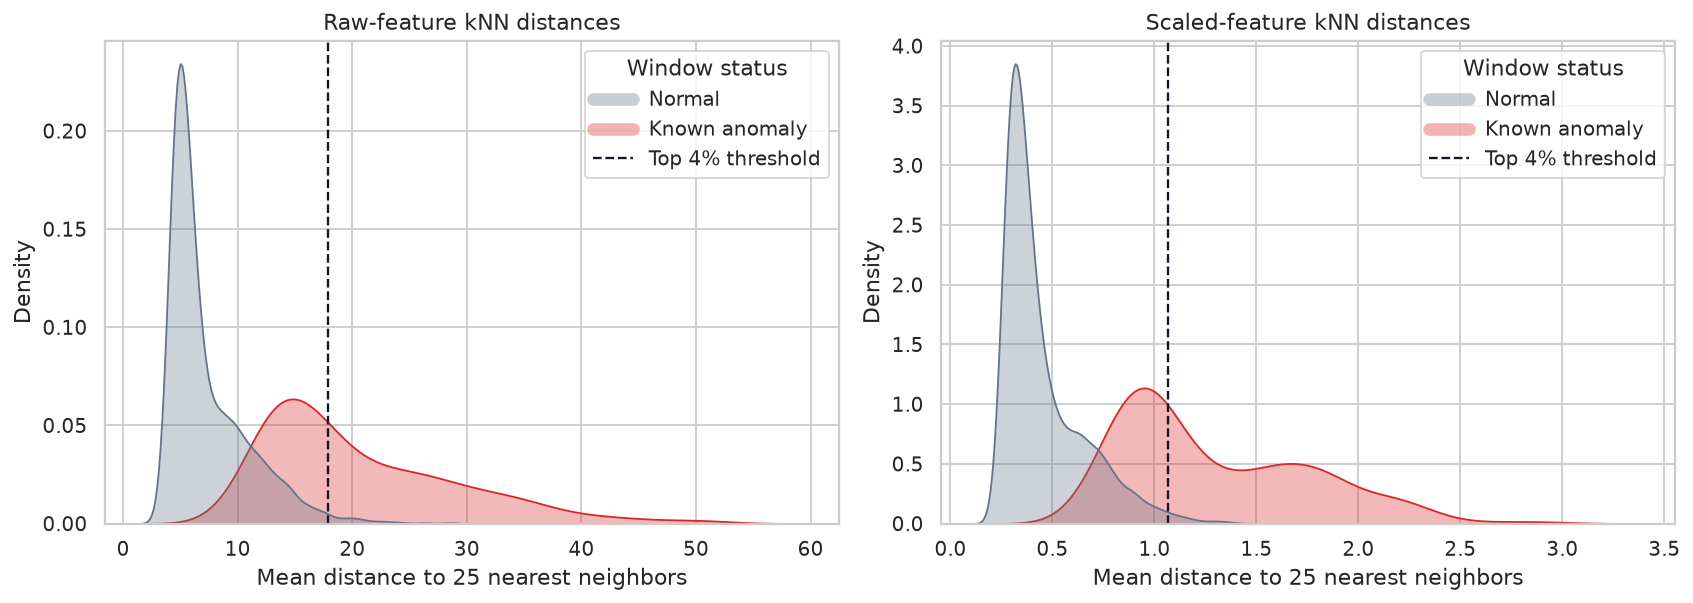

In [5]:
# Section focus: 4. Feature Scaling and kNN Scores.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

for score_col, cutoff, title, ax in [
    ('knn_raw_mean_distance', knn_cut_raw, 'Raw-feature kNN distances', axes[0]),
    ('knn_scaled_mean_distance', knn_cut_scaled, 'Scaled-feature kNN distances', axes[1]),
]:
    sns.kdeplot(
        data=df,
        x=score_col,
        hue='known_anomaly',
        common_norm=False,
        fill=True,
        alpha=0.32,
        palette={0: '#64748b', 1: '#dc2626'},
        ax=ax,
    )
    ax.axvline(cutoff, color='#111827', linestyle='--', linewidth=1.3, label='Top 4% threshold')
    ax.set_title(title)
    ax.set_xlabel('Mean distance to 25 nearest neighbors')
    ax.set_ylabel('Density')
    ax.legend(
        handles=[
            Line2D([0], [0], color='#64748b', linewidth=7, alpha=0.35, label='Normal'),
            Line2D([0], [0], color='#dc2626', linewidth=7, alpha=0.35, label='Known anomaly'),
            Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.3, label='Top 4% threshold'),
        ],
        title='Window status',
    )

plt.tight_layout()
plt.show()

Raw distance has units. Scaled distance has modeling assumptions. Neither is neutral. The correct preprocessing depends on what differences should matter operationally.

For most tabular monitoring problems, standardized or robustly scaled features are a better starting point than raw Euclidean distance. But if business rules say one variable should dominate, use an explicit weight rather than leaving that decision to unit scales.

## 5. Local Outlier Factor

LOF compares a point's local density to the local density of its neighbors. In scikit-learn, larger values of `-negative_outlier_factor_` indicate stronger outlierness. Values near 1 mean the point has density comparable to its neighborhood.

We will compare three scores under the same review budget:

| Score | Interpretation |
|---|---|
| Raw kNN mean distance | Isolation in original units |
| Scaled kNN mean distance | Isolation after standardization |
| LOF score | Local density deficit relative to neighbors |

In [6]:
# Section focus: 5. Local Outlier Factor.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

lof_model = LocalOutlierFactor(n_neighbors=k, metric='euclidean')
lof_model.fit_predict(X_scaled)
df['lof_score'] = -lof_model.negative_outlier_factor_

lof_cut = df['lof_score'].quantile(1 - review_rate)

thresholds = {
    'Raw kNN distance': ('knn_raw_mean_distance', knn_cut_raw),
    'Scaled kNN distance': ('knn_scaled_mean_distance', knn_cut_scaled),
    'LOF local density': ('lof_score', lof_cut),
}

def detector_metrics(frame, score_col, cutoff, label):
    """Carry out the detector metrics step used in the 05. Distance-Based Methods: kNN and Local Outlier Factor workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    alert = frame[score_col] >= cutoff
    y = frame['known_anomaly'].eq(1)
    tp = int((alert & y).sum())
    fp = int((alert & ~y).sum())
    fn = int((~alert & y).sum())
    tn = int((~alert & ~y).sum())
    return {
        'detector': label,
        'cutoff': cutoff,
        'alerts': int(alert.sum()),
        'alert_rate': alert.mean(),
        'precision': tp / (tp + fp) if tp + fp else np.nan,
        'recall': tp / (tp + fn) if tp + fn else np.nan,
        'false_positive_rate': fp / (fp + tn) if fp + tn else np.nan,
        'roc_auc': roc_auc_score(frame['known_anomaly'], frame[score_col]),
        'average_precision': average_precision_score(frame['known_anomaly'], frame[score_col]),
        'workload_hours': frame.loc[alert, 'review_minutes'].sum() / 60,
        'normal_enterprise_share_of_alerts': frame.loc[alert, 'anomaly_type'].eq('normal_enterprise').mean() if alert.sum() else np.nan,
    }

metrics = pd.DataFrame([
    detector_metrics(df, score_col, cutoff, label)
    for label, (score_col, cutoff) in thresholds.items()
])
metrics_display = metrics.copy()
metrics_display['cutoff'] = metrics_display['cutoff'].map(lambda value: f'{value:.2f}')
metrics_display['workload_hours'] = metrics_display['workload_hours'].map(lambda value: f'{value:.1f}')
for column in ['alert_rate', 'precision', 'recall', 'false_positive_rate', 'average_precision', 'normal_enterprise_share_of_alerts']:
    metrics_display[column] = metrics_display[column].map(lambda value: f'{value:.1%}')
metrics_display['roc_auc'] = metrics_display['roc_auc'].map(lambda value: f'{value:.3f}')
smart_display(metrics_display, max_width='1080px')

,detector,cutoff,alerts,alert_rate,precision,recall,false_positive_rate,roc_auc,average_precision,workload_hours,normal_enterprise_share_of_alerts
0,Raw kNN distance,17.86,180,4.0%,66.7%,50.0%,1.4%,0.967,66.6%,62.9,32.2%
1,Scaled kNN distance,1.07,180,4.0%,71.7%,53.8%,1.2%,0.979,75.9%,62.7,27.8%
2,LOF local density,1.29,180,4.0%,3.9%,2.9%,4.1%,0.411,4.4%,47.8,29.4%


The practical reading of Local Outlier Factor is whether the flagged cases point to an action a team can defend.


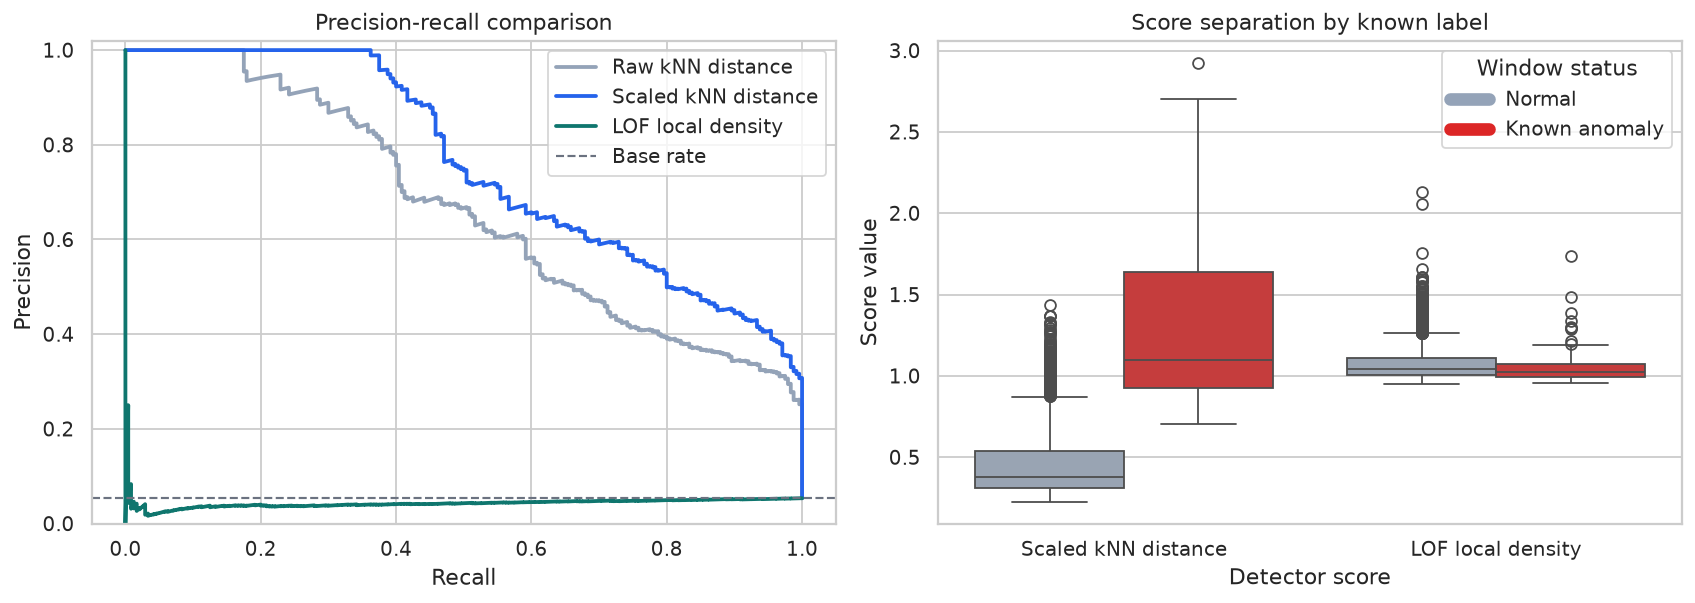

In [7]:
# Section focus: 5. Local Outlier Factor.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

for score_col, label, color in [
    ('knn_raw_mean_distance', 'Raw kNN distance', '#94a3b8'),
    ('knn_scaled_mean_distance', 'Scaled kNN distance', '#2563eb'),
    ('lof_score', 'LOF local density', '#0f766e'),
]:
    precision, recall, _ = precision_recall_curve(df['known_anomaly'], df[score_col])
    axes[0].plot(recall, precision, linewidth=2.1, label=label, color=color)
axes[0].axhline(df['known_anomaly'].mean(), color='#6b7280', linestyle='--', linewidth=1.2, label='Base rate')
axes[0].set_title('Precision-recall comparison')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1.02)
axes[0].legend()

score_long = df.melt(
    id_vars=['known_anomaly'],
    value_vars=['knn_scaled_mean_distance', 'lof_score'],
    var_name='score_type',
    value_name='score_value',
)
score_long['score_type'] = score_long['score_type'].map({
    'knn_scaled_mean_distance': 'Scaled kNN distance',
    'lof_score': 'LOF local density',
})
sns.boxplot(
    data=score_long,
    x='score_type',
    y='score_value',
    hue='known_anomaly',
    palette={0: '#94a3b8', 1: '#dc2626'},
    ax=axes[1],
)
axes[1].set_title('Score separation by known label')
axes[1].set_xlabel('Detector score')
axes[1].set_ylabel('Score value')
axes[1].legend(
    handles=[
        Line2D([0], [0], color='#94a3b8', linewidth=7, label='Normal'),
        Line2D([0], [0], color='#dc2626', linewidth=7, label='Known anomaly'),
    ],
    title='Window status',
)

plt.tight_layout()
plt.show()

The fixed review budget keeps the comparison fair: each detector is allowed to send the same share of windows to review. That lets us ask which detector fills the queue with more useful cases.

In this simulated run, LOF performs poorly. That is not a coding error; it is a useful warning. LOF estimates local density from the same heterogeneous neighborhood graph that contains standard windows, enterprise windows, bridge-like cases, and degradation cases. When density varies for reasons that are not true failures, LOF can assign high outlier scores to sparse-but-normal cases.

The decision-science conclusion is therefore evidence-driven: use scaled kNN as the stronger operating score here, and keep LOF as a diagnostic comparison and stress test rather than the recommended first-pass detector.

## 6. Geometry in a Two-Dimensional View

To see why local density matters, we project the standardized features into two principal components. This is only a visualization; the detectors still use all standardized features.

The point of the plot is to compare how kNN and LOF allocate the same review budget across dense regions, sparse normal regions, and anomaly regions.

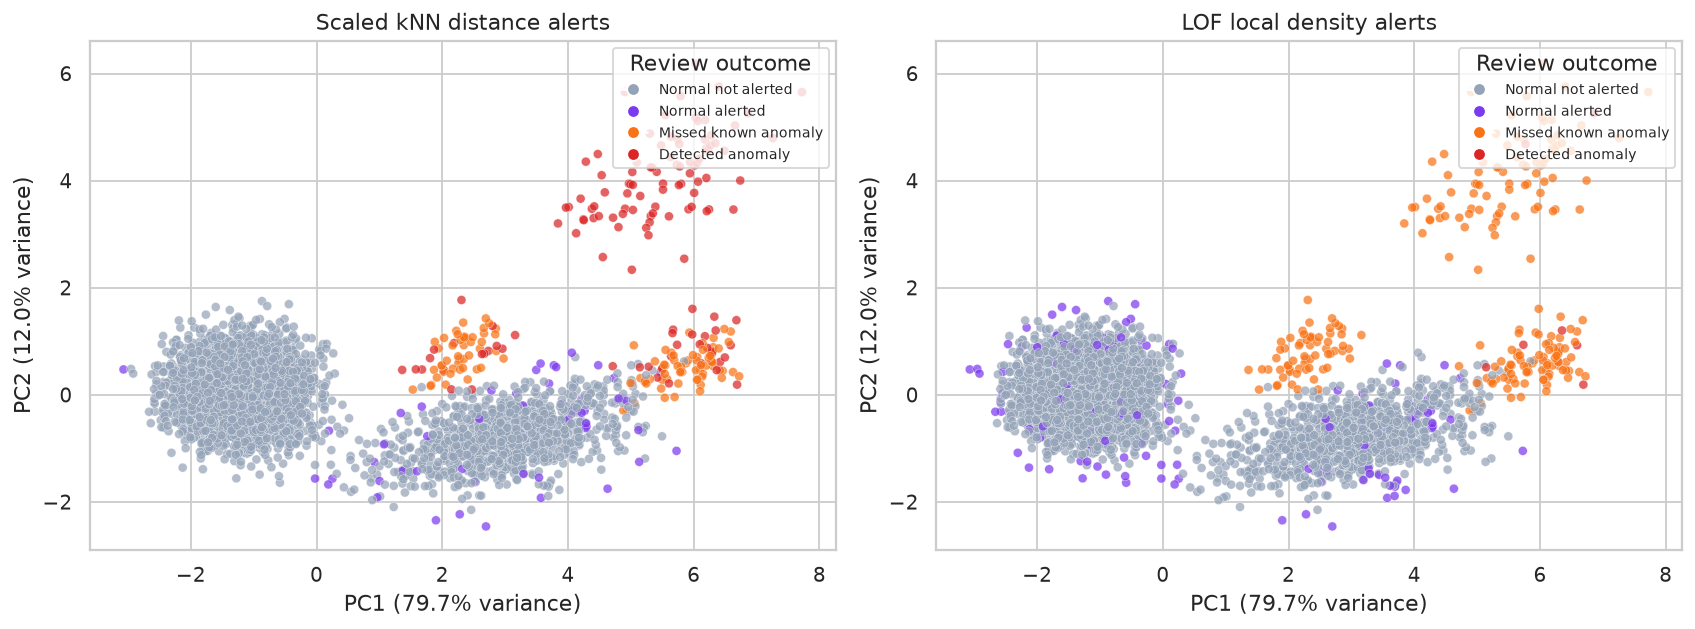

In [8]:
# Section focus: 6. Geometry in a Two-Dimensional View.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)
plot_df = df.copy()
plot_df['pc1'] = coords[:, 0]
plot_df['pc2'] = coords[:, 1]
plot_df['scaled_knn_alert'] = plot_df['knn_scaled_mean_distance'] >= knn_cut_scaled
plot_df['lof_alert'] = plot_df['lof_score'] >= lof_cut

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
status_order = ['Normal not alerted', 'Normal alerted', 'Missed known anomaly', 'Detected anomaly']
palette = {
    'Normal not alerted': '#94a3b8',
    'Normal alerted': '#7c3aed',
    'Missed known anomaly': '#f97316',
    'Detected anomaly': '#dc2626',
}

for ax, alert_col, title in [
    (axes[0], 'scaled_knn_alert', 'Scaled kNN distance alerts'),
    (axes[1], 'lof_alert', 'LOF local density alerts'),
]:
    status = np.select(
        [plot_df['known_anomaly'].eq(0) & plot_df[alert_col], plot_df['known_anomaly'].eq(1) & ~plot_df[alert_col], plot_df['known_anomaly'].eq(1) & plot_df[alert_col]],
        ['Normal alerted', 'Missed known anomaly', 'Detected anomaly'],
        default='Normal not alerted',
    )
    plot_data = plot_df.assign(status=pd.Categorical(status, categories=status_order, ordered=True))
    sns.scatterplot(
        data=plot_data.sample(frac=1, random_state=RANDOM_SEED),
        x='pc1',
        y='pc2',
        hue='status',
        hue_order=status_order,
        palette=palette,
        s=25,
        alpha=0.72,
        edgecolor='white',
        linewidth=0.25,
        ax=ax,
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.legend(
        handles=[
            Line2D([0], [0], marker='o', color='white', markerfacecolor=palette[name], markeredgecolor='white', markersize=7, label=name)
            for name in status_order
        ],
        title='Review outcome',
        loc='upper right',
        fontsize=8,
    )

plt.tight_layout()
plt.show()

The PCA plot should not be used as the detector itself. It is a diagnostic view. It helps answer operational questions such as:

- Is the detector alerting an entire sparse normal group?
- Are known anomalies concentrated in a region that the detector misses?
- Are false alerts near regime boundaries where segmentation might help?

Distance-based methods often improve when the baseline is segmented. A single global neighbor graph may not be the right object if the business contains several genuinely different operating modes.

## 7. Neighborhood Size Sensitivity

The neighborhood size $k$ controls the scale of locality:

- Small $k$ reacts to very local irregularity but can be noisy.
- Large $k$ smooths over local structure but can treat sparse normal groups as abnormal.

There is no universally correct $k$. It should be treated as a design parameter and checked for stability.

In [9]:
k_grid = [5, 10, 20, 35, 50, 80]
stability_rows = []
for k_value in k_grid:
    nn = NearestNeighbors(n_neighbors=k_value + 1).fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    score = distances[:, 1:].mean(axis=1)
    cutoff = np.quantile(score, 1 - review_rate)
    stability_rows.append(detector_metrics(df.assign(temp_score=score), 'temp_score', cutoff, f'kNN k={k_value}'))

    lof = LocalOutlierFactor(n_neighbors=k_value, metric='euclidean')
    lof.fit_predict(X_scaled)
    lof_score = -lof.negative_outlier_factor_
    lof_cutoff = np.quantile(lof_score, 1 - review_rate)
    stability_rows.append(detector_metrics(df.assign(temp_score=lof_score), 'temp_score', lof_cutoff, f'LOF k={k_value}'))

stability = pd.DataFrame(stability_rows)
stability_display = stability[['detector', 'alerts', 'precision', 'recall', 'normal_enterprise_share_of_alerts', 'workload_hours']].copy()
stability_display['workload_hours'] = stability_display['workload_hours'].map(lambda value: f'{value:.1f}')
for column in ['precision', 'recall', 'normal_enterprise_share_of_alerts']:
    stability_display[column] = stability_display[column].map(lambda value: f'{value:.1%}')
smart_display(stability_display, max_width='920px')

,detector,alerts,precision,recall,normal_enterprise_share_of_alerts,workload_hours
0,kNN k=5,180,66.7%,50.0%,32.8%,62.7
1,LOF k=5,180,8.3%,6.2%,27.8%,48.3
2,kNN k=10,180,66.7%,50.0%,32.8%,62.3
3,LOF k=10,180,6.7%,5.0%,30.6%,48.3
4,kNN k=20,180,69.4%,52.1%,30.0%,62.7
5,LOF k=20,180,3.9%,2.9%,30.0%,47.4
6,kNN k=35,180,74.4%,55.8%,25.0%,62.8
7,LOF k=35,180,2.8%,2.1%,27.8%,47.7
8,kNN k=50,180,77.8%,58.3%,22.2%,63.1
9,LOF k=50,180,1.7%,1.2%,25.6%,46.4


For Neighborhood Size Sensitivity, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


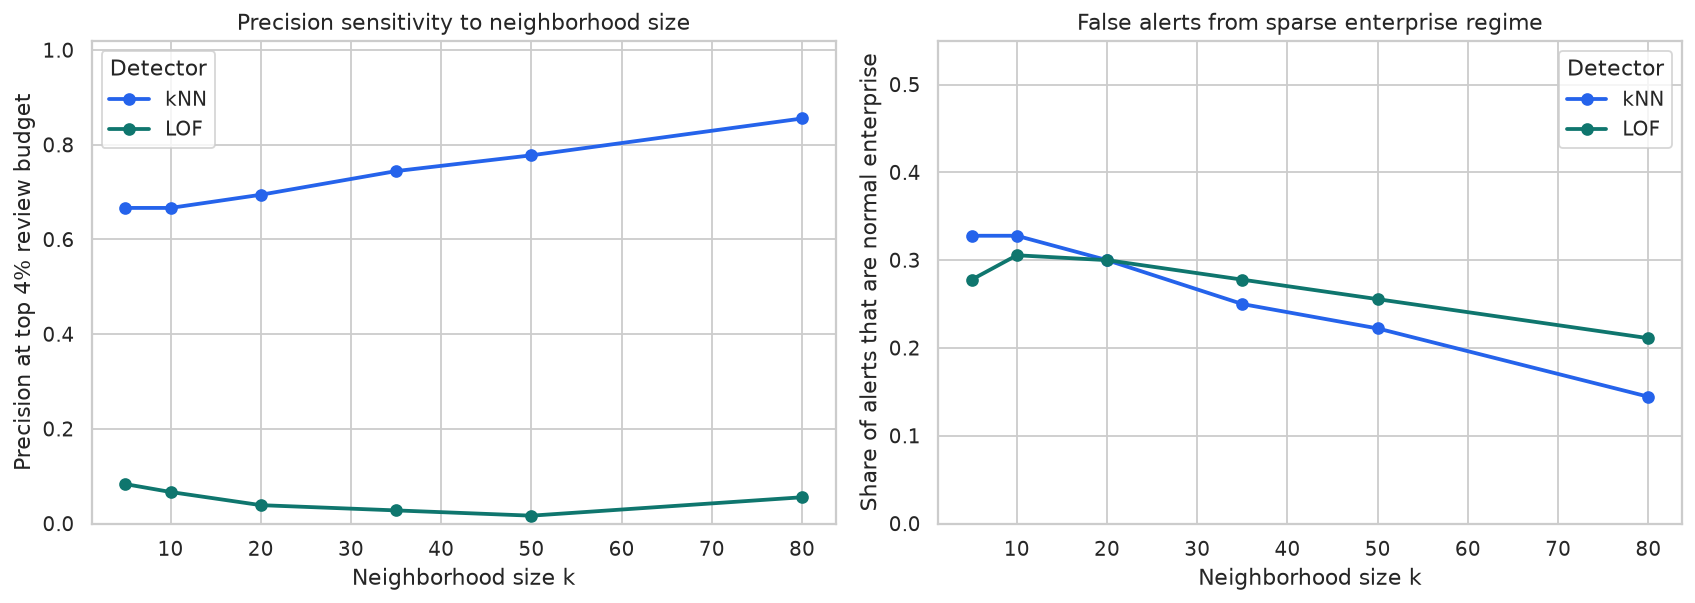

In [10]:
stability_plot = stability.copy()
stability_plot['method'] = stability_plot['detector'].str.extract(r'^(kNN|LOF)')
stability_plot['k'] = stability_plot['detector'].str.extract(r'k=(\d+)').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
for method, color in [('kNN', '#2563eb'), ('LOF', '#0f766e')]:
    subset = stability_plot.loc[stability_plot['method'].eq(method)]
    axes[0].plot(subset['k'], subset['precision'], marker='o', linewidth=2.1, color=color, label=method)
    axes[1].plot(subset['k'], subset['normal_enterprise_share_of_alerts'], marker='o', linewidth=2.1, color=color, label=method)

axes[0].set_title('Precision sensitivity to neighborhood size')
axes[0].set_xlabel('Neighborhood size k')
axes[0].set_ylabel('Precision at top 4% review budget')
axes[0].set_ylim(0, 1.02)
axes[0].legend(title='Detector')

axes[1].set_title('False alerts from sparse enterprise regime')
axes[1].set_xlabel('Neighborhood size k')
axes[1].set_ylabel('Share of alerts that are normal enterprise')
axes[1].set_ylim(0, max(0.55, stability_plot['normal_enterprise_share_of_alerts'].max() + 0.05))
axes[1].legend(title='Detector')

plt.tight_layout()
plt.show()

A detector that only works for one convenient $k$ is fragile. Stability plots turn tuning into governance. The better question asks whether the recommendation remains credible across reasonable neighborhood choices, instead of only asking which $k$ gives the best number.

Neighborhood Size Sensitivity is less about the score itself and more about whether the score creates an actionable investigation path.


## 8. Explaining a Distance-Based Alert

Distance alerts are easier to trust when the reviewer can see the nearest-neighbor context. For a selected alert from the recommended scaled kNN detector, we can show:

1. The case's feature values.
2. The average feature values of its nearest neighbors.
3. The standardized difference between the case and its neighborhood.

This makes the alert actionable without pretending that kNN or LOF is a causal explanation.

In [11]:
# Section focus: 8. Explaining a Distance-Based Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

selected_case = int(df.loc[df['knn_scaled_mean_distance'].ge(knn_cut_scaled)].sort_values('knn_scaled_mean_distance', ascending=False).index[0])
neighbor_ids = scaled_indices[selected_case, 1:k + 1]
case_values = df.loc[selected_case, features]
neighbor_means = df.loc[neighbor_ids, features].mean()
neighbor_stds = df.loc[neighbor_ids, features].std(ddof=1).replace(0, np.nan)
neighbor_z = ((case_values - neighbor_means) / neighbor_stds).replace([np.inf, -np.inf], np.nan)

explanation = pd.DataFrame({
    'feature': features,
    'case_value': case_values.values,
    'neighbor_mean': neighbor_means.values,
    'neighbor_standardized_gap': neighbor_z.values,
})
explanation['feature'] = explanation['feature'].map({
    'ticket_volume': 'Ticket volume',
    'median_resolution_minutes': 'Median resolution minutes',
    'escalation_rate_pct': 'Escalation rate (%)',
    'reopen_rate_pct': 'Reopen rate (%)',
    'cost_per_ticket': 'Cost per ticket',
    'customer_risk_score': 'Customer risk score',
})
explanation_display = explanation.copy()
for column in ['case_value', 'neighbor_mean', 'neighbor_standardized_gap']:
    explanation_display[column] = explanation_display[column].map(lambda value: '' if pd.isna(value) else f'{value:.2f}')
smart_display(explanation_display, max_width='900px')

case_context = pd.DataFrame({
    'Quantity': ['Selected case id', 'Known label', 'Anomaly type', 'Scaled kNN mean distance', 'LOF score', 'Nearest-neighbor normal enterprise share'],
    'Value': [
        selected_case,
        int(df.loc[selected_case, 'known_anomaly']),
        df.loc[selected_case, 'anomaly_type'],
        f"{df.loc[selected_case, 'knn_scaled_mean_distance']:.2f}",
        f"{df.loc[selected_case, 'lof_score']:.2f}",
        f"{df.loc[neighbor_ids, 'anomaly_type'].eq('normal_enterprise').mean():.1%}",
    ],
})
smart_display(case_context, max_width='780px')

,feature,case_value,neighbor_mean,neighbor_standardized_gap
0,Ticket volume,186.37,167.41,1.10
1,Median resolution minutes,142.50,133.17,0.41
2,Escalation rate (%),47.63,33.08,5.11
3,Reopen rate (%),19.20,18.76,0.16
4,Cost per ticket,91.22,92.79,-0.11
5,Customer risk score,84.63,89.71,-0.61


,Quantity,Value
0,Selected case id,4341
1,Known label,1
2,Anomaly type,global_service_breakdown
3,Scaled kNN mean distance,2.93
4,LOF score,1.38
5,Nearest-neighbor normal enterprise share,0.0%


Read Explaining a Distance-Based Alert with the reviewer in mind. The output should reduce noise in the review process.


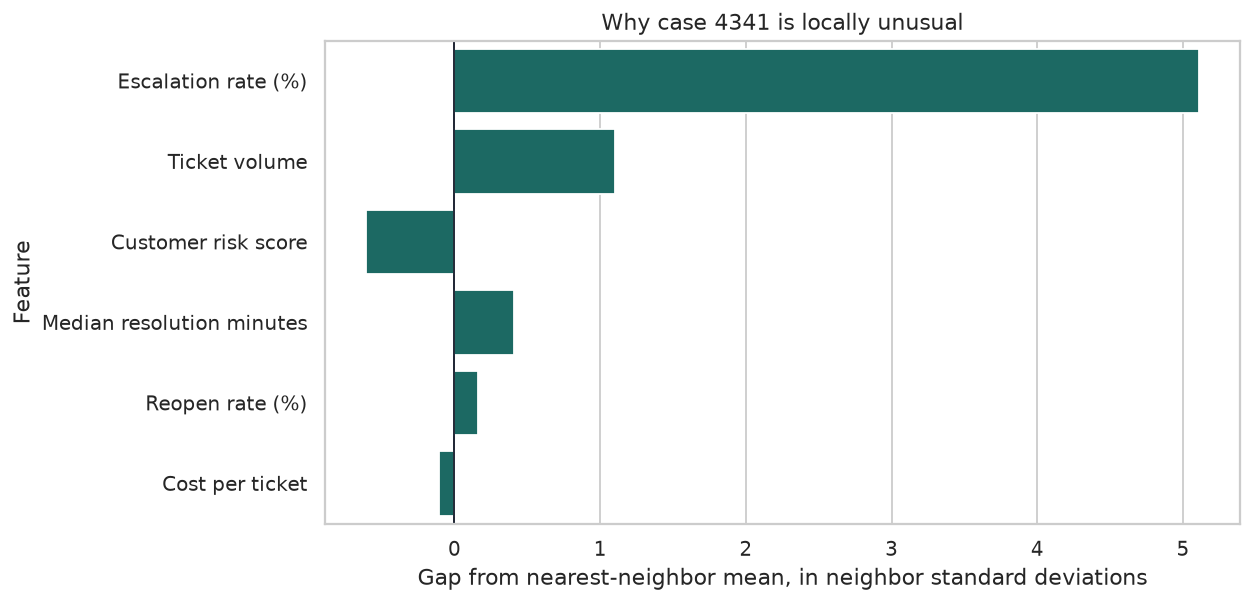

In [12]:
fig, ax = plt.subplots(figsize=(9.8, 4.8))
plot_explanation = explanation.sort_values('neighbor_standardized_gap', key=lambda col: col.abs(), ascending=False)
sns.barplot(
    data=plot_explanation,
    x='neighbor_standardized_gap',
    y='feature',
    ax=ax,
    color='#0f766e',
)
ax.axvline(0, color='#111827', linewidth=1.0)
ax.set_title(f'Why case {selected_case} is locally unusual')
ax.set_xlabel('Gap from nearest-neighbor mean, in neighbor standard deviations')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

This explanation is local: it compares the alert to its neighbors, not to the whole dataset. That is the right explanatory frame for nearest-neighbor detectors. If the selected case has much higher resolution time, escalation, or cost than nearby cases, the alert has an operational story.

For deployment, this table should be part of the alert payload. It gives the reviewer enough context to decide whether the case deserves escalation, suppression, or feedback into the detector design.

## 9. Decision Memo

The final step is to translate detector comparison into an operating recommendation. The memo should state the score, threshold, queue size, expected performance, known risks, and monitoring plan.

In [13]:
# Section focus: 9. Decision Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended = metrics.loc[metrics['detector'].eq('Scaled kNN distance')].iloc[0]
raw_knn = metrics.loc[metrics['detector'].eq('Raw kNN distance')].iloc[0]
lof_row = metrics.loc[metrics['detector'].eq('LOF local density')].iloc[0]

memo = pd.DataFrame({
    'Memo item': [
        'Recommended detector',
        'Operating threshold',
        'Expected queue size',
        'Expected precision and recall',
        'Why not raw distance?',
        'Why not LOF here?',
        'Main risks',
        'Monitoring plan',
    ],
    'Decision note': [
        'Use scaled kNN mean distance as the first-pass review score for this dataset.',
        f"Flag the top {review_rate:.0%} of windows by scaled kNN distance; current cutoff is {knn_cut_scaled:.2f}.",
        f"Expected alert rate is {recommended['alert_rate']:.1%}, or about {int(recommended['alerts'])} windows in this batch, requiring about {recommended['workload_hours']:.1f} review hours.",
        f"Estimated precision is {recommended['precision']:.1%}; estimated recall is {recommended['recall']:.1%} using the synthetic known labels.",
        f"Raw distance mixes measurement units and has lower precision here ({raw_knn['precision']:.1%}) than scaled kNN.",
        f"LOF is theoretically useful for local density, but in this heterogeneous-regime simulation its precision is only {lof_row['precision']:.1%}; it appears to confuse sparse normal structure with anomalies.",
        'kNN can still over-alert sparse normal regimes and is sensitive to feature scaling, duplicated observations, and the neighborhood size k.',
        'Track review precision, alert volume by regime, nearest-neighbor composition, score drift, and stability across reasonable k values. Keep LOF as a comparison diagnostic, not the primary launch rule.',
    ],
})
smart_display(memo, max_width='1020px')

,Memo item,Decision note
0,Recommended detector,Use scaled kNN mean distance as the first-pass review score for this dataset.
1,Operating threshold,Flag the top 4% of windows by scaled kNN distance; current cutoff is 1.07.
2,Expected queue size,"Expected alert rate is 4.0%, or about 180 windows in this batch, requiring about 62.7 review hours."
3,Expected precision and recall,Estimated precision is 71.7%; estimated recall is 53.8% using the synthetic known labels.
4,Why not raw distance?,Raw distance mixes measurement units and has lower precision here (66.7%) than scaled kNN.
5,Why not LOF here?,"LOF is theoretically useful for local density, but in this heterogeneous-regime simulation its precision is only 3.9%; it appears to confuse sparse normal structure with anomalies."
6,Main risks,"kNN can still over-alert sparse normal regimes and is sensitive to feature scaling, duplicated observations, and the neighborhood size k."
7,Monitoring plan,"Track review precision, alert volume by regime, nearest-neighbor composition, score drift, and stability across reasonable k values. Keep LOF as a comparison diagnostic, not the primary launch rule."


In Decision Memo, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


## Key Takeaways

- Distance-based anomaly detection depends on the definition of distance; feature scaling is part of the model.
- kNN distance scores identify globally isolated points.
- LOF identifies points whose local density is lower than their neighbors' local density.
- Fixed review budgets make detector comparisons operationally meaningful.
- LOF still needs the same practical checks as kNN. In heterogeneous regimes, local density estimation can confuse sparse normal structure with anomalies.
- Neighborhood size $k$ should be stress-tested, not chosen once and forgotten.
- Distance-based alerts need local explanations: nearest-neighbor context, feature gaps, and regime composition.
- In production, distance detectors should be monitored for score drift, changing regimes, and review feedback.

## References

Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying density-based local outliers. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 93-104. [https://doi.org/10.1145/342009.335388](https://doi.org/10.1145/342009.335388)

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Mathew, X., Ngan, H. Y. T., & Liu, W. (2016). Density-based outlier detection by Local Outlier Factor on large-scale traffic data. *Electronic Imaging, 28*(14), 1-4. [https://doi.org/10.2352/ISSN.2470-1173.2016.14.IPMVA-385](https://doi.org/10.2352/ISSN.2470-1173.2016.14.IPMVA-385)

Ramaswamy, S., Rastogi, R., & Shim, K. (2000). Efficient algorithms for mining outliers from large data sets. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 427-438. [https://doi.org/10.1145/342009.335437](https://doi.org/10.1145/342009.335437)
